In [ ]:
!pip install torch joblib scikit-learn matplotlib pandas

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")

In [57]:
df = pd.read_csv("/kaggle/input/datasets/ngyyenhon/iotdtt/iot.csv")
df.head()

,Device_ID,Temperature,Humidity,Battery_Level,Anomaly
0,DHT11_B,-0.555734,-0.157264,0.377032,0
1,DHT11_A,-0.266879,-0.086229,-0.217410,0
2,DHT11_B,0.128544,0.041150,0.090479,0
3,TEST_SENSOR_999,99.999000,88.888000,77.777000,1
4,DHT11_D,-1.001516,-0.320621,-0.705341,0


In [58]:
df.describe()
df["Device_ID"].value_counts()
df["Anomaly"].value_counts()

Anomaly
0    2478
1     523
Name: count, dtype: int64

In [59]:
df.isna().sum()

Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64

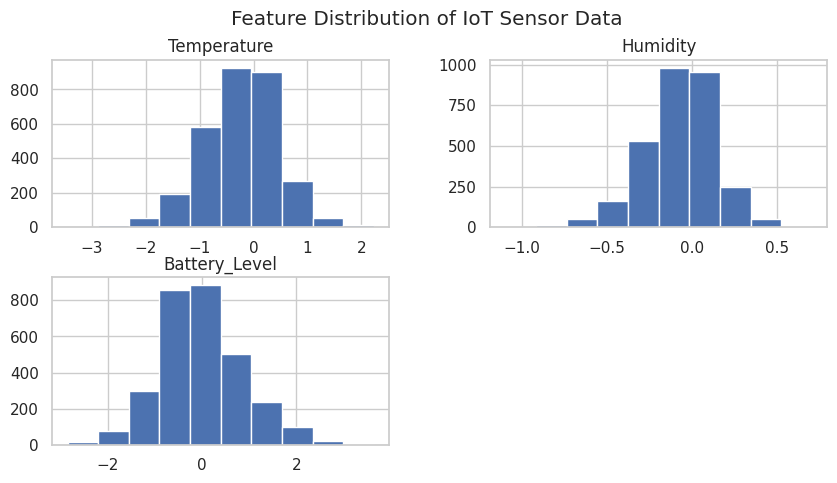

In [ ]:
df[['Temperature', 'Humidity', 'Battery_Level']].hist(figsize=(10,5))
plt.suptitle("Feature Distribution of IoT Sensor Data")
plt.show()

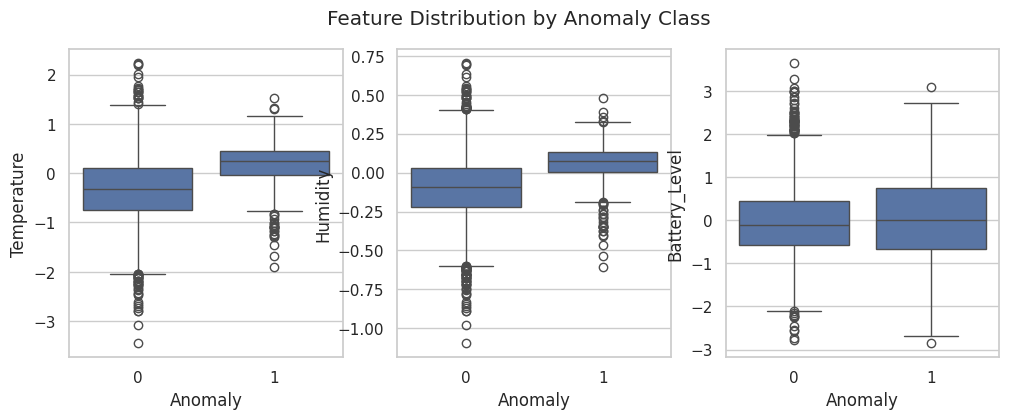

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(x='Anomaly', y='Temperature', data=df)

plt.subplot(1,3,2)
sns.boxplot(x='Anomaly', y='Humidity', data=df)

plt.subplot(1,3,3)
sns.boxplot(x='Anomaly', y='Battery_Level', data=df)

plt.suptitle("Feature Distribution by Anomaly Class")
plt.show()

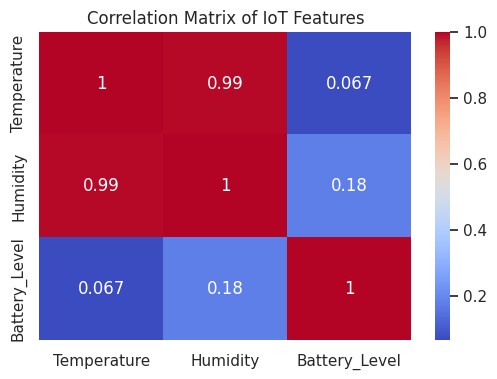

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Temperature','Humidity','Battery_Level']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of IoT Features")
plt.show()

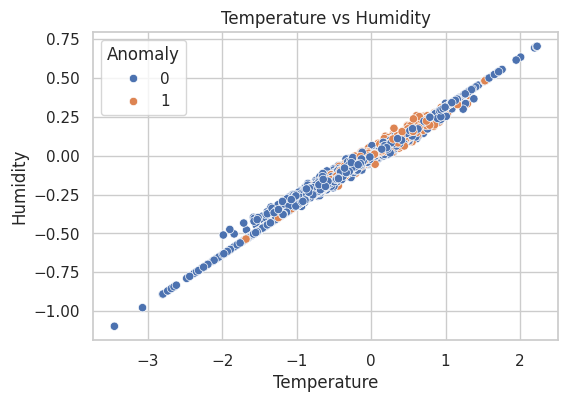

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Temperature', y='Humidity', hue='Anomaly', data=df)
plt.title("Temperature vs Humidity")
plt.show()

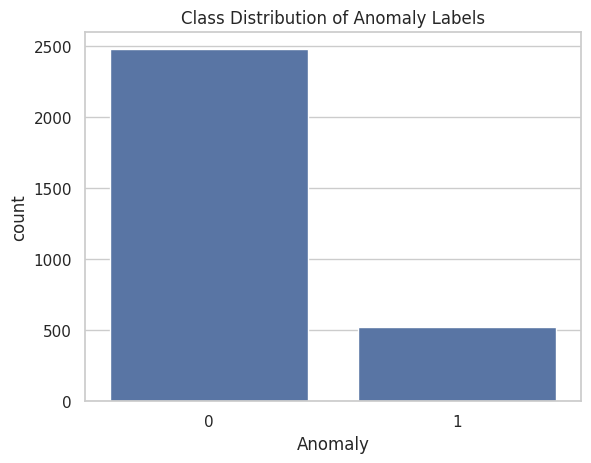

Anomaly
0    0.826
1    0.174
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='Anomaly', data=df)
plt.title("Class Distribution of Anomaly Labels")
plt.show()

print(df['Anomaly'].value_counts(normalize=True))

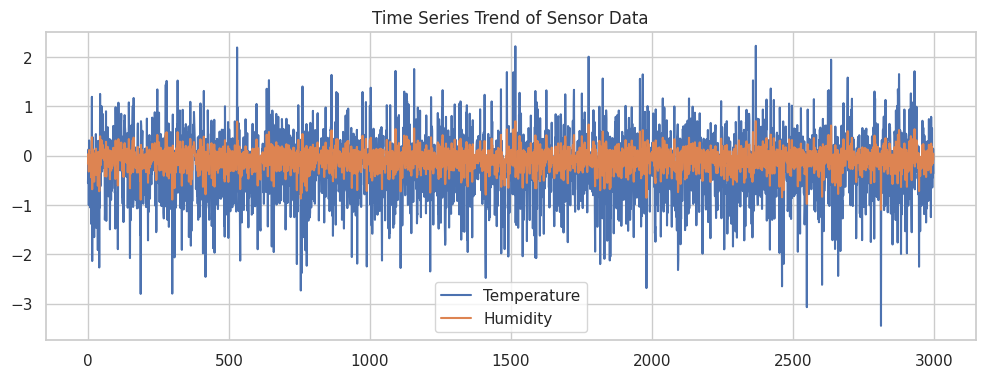

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df['Temperature'], label='Temperature')
plt.plot(df['Humidity'], label='Humidity')
plt.legend()
plt.title("Time Series Trend of Sensor Data")
plt.show()

In [ ]:
import pandas as pd

cols = ["Temperature", "Humidity", "Battery_Level", "Anomaly"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

df["temp_diff"] = df["Temperature"].diff()
df["hum_diff"] = df["Humidity"].diff()
df["bat_diff"] = df["Battery_Level"].diff()

df["temp_mean10"] = df["Temperature"].rolling(10).mean()
df["temp_std10"]  = df["Temperature"].rolling(10).std()

df["hum_mean10"] = df["Humidity"].rolling(10).mean()
df["hum_std10"]  = df["Humidity"].rolling(10).std()

df = df.dropna().reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    "Temperature", "Humidity", "Battery_Level",
    "temp_diff", "hum_diff", "bat_diff",
    "temp_mean10", "temp_std10",
    "hum_mean10", "hum_std10",
]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

y_all = df["Anomaly"].values

In [ ]:
WINDOW = 50
X, y = [], []

data = df[features].values
labels = df["Anomaly"].values

for i in range(len(data) - WINDOW):
    X.append(data[i:i+WINDOW])
    y.append(labels[i+WINDOW-1])

X = np.array(X)
y = np.array(y)

print(np.unique(y, return_counts=True))

(array([0, 1]), array([2418,  514]))


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True
)

In [ ]:
print("y_train unique:", np.unique(y_train, return_counts=True))
print("y_test  unique:", np.unique(y_test,  return_counts=True))

y_train unique: (array([0, 1]), array([1934,  411]))
y_test  unique: (array([0, 1]), array([484, 103]))


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(SeqDataset(X_test, y_test), batch_size=64, shuffle=False)

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            256,
            num_layers=3,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMModel(len(features)).to(device)

pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = torch.tensor([neg/pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
from sklearn.metrics import f1_score
import numpy as np

model.eval()
probs = []
true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = torch.sigmoid(model(xb))
        probs.extend(out.cpu().numpy())
        true.extend(yb.numpy())

probs = np.array(probs).flatten()
true = np.array(true)

In [ ]:
best_f1 = 0
best_th = 0

for th in np.arange(0.05, 0.95, 0.01):
    pred = (probs > th).astype(int)
    f1 = f1_score(true, pred)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print("Best threshold:", best_th)
print("Best F1:", best_f1)

Best threshold: 0.16000000000000003
Best F1: 0.40522875816993464


In [ ]:
from sklearn.metrics import classification_report

final_pred = (probs > best_th).astype(int)
print(classification_report(true, final_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.71      0.79       484
         1.0       0.31      0.60      0.41       103

    accuracy                           0.69       587
   macro avg       0.60      0.66      0.60       587
weighted avg       0.79      0.69      0.72       587



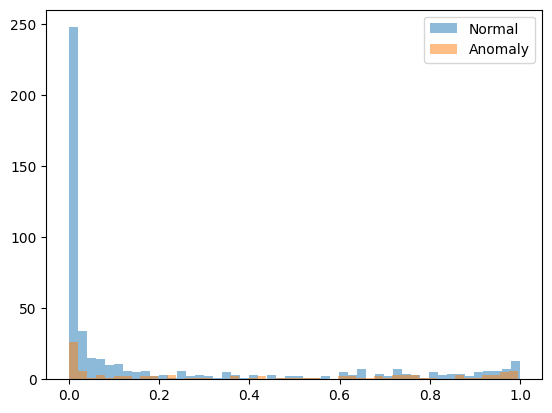

In [ ]:
import matplotlib.pyplot as plt

plt.hist(probs[true==0], bins=50, alpha=0.5, label="Normal")
plt.hist(probs[true==1], bins=50, alpha=0.5, label="Anomaly")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

cols = ["Temperature", "Humidity", "Battery_Level", "Anomaly"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

df["temp_diff"] = df["Temperature"].diff()
df["hum_diff"] = df["Humidity"].diff()
df["bat_diff"] = df["Battery_Level"].diff()

df["temp_mean10"] = df["Temperature"].rolling(10).mean()
df["temp_std10"]  = df["Temperature"].rolling(10).std()

df["hum_mean10"] = df["Humidity"].rolling(10).mean()
df["hum_std10"]  = df["Humidity"].rolling(10).std()

df = df.dropna().reset_index(drop=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    "Temperature", "Humidity", "Battery_Level",
    "temp_diff", "hum_diff", "bat_diff",
    "temp_mean10", "temp_std10",
    "hum_mean10", "hum_std10",
]

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

y_all = df["Anomaly"].values

In [ ]:
WINDOW = 80
X, y = [], []

data = df[features].values
labels = df["Anomaly"].values

for i in range(len(data) - WINDOW):
    X.append(data[i:i+WINDOW])
    y.append(labels[i+WINDOW-1])

X = np.array(X)
y = np.array(y)

print(np.unique(y, return_counts=True))

(array([0, 1]), array([2402,  509]))


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, shuffle=True
)

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(SeqDataset(X_test, y_test), batch_size=64, shuffle=False)

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            256,
            num_layers=3,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(256, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMModel(len(features)).to(device)

pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = torch.tensor([neg/pos]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device).unsqueeze(1)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 1.1427
Epoch 2, Loss: 1.0394
Epoch 3, Loss: 0.9876
Epoch 4, Loss: 0.9497
Epoch 5, Loss: 0.9378
Epoch 6, Loss: 0.9289
Epoch 7, Loss: 0.9141
Epoch 8, Loss: 0.9007
Epoch 9, Loss: 0.9007
Epoch 10, Loss: 0.8892
Epoch 11, Loss: 0.8827
Epoch 12, Loss: 0.8702
Epoch 13, Loss: 0.8491
Epoch 14, Loss: 0.8472
Epoch 15, Loss: 0.8337
Epoch 16, Loss: 0.8017
Epoch 17, Loss: 0.8185
Epoch 18, Loss: 0.7761
Epoch 19, Loss: 0.7540
Epoch 20, Loss: 0.6978
Epoch 21, Loss: 0.6801
Epoch 22, Loss: 0.6877
Epoch 23, Loss: 0.6677
Epoch 24, Loss: 0.6062
Epoch 25, Loss: 0.6514
Epoch 26, Loss: 0.5920
Epoch 27, Loss: 0.5567
Epoch 28, Loss: 0.5042
Epoch 29, Loss: 0.4155
Epoch 30, Loss: 0.3823


In [ ]:
from sklearn.metrics import f1_score
import numpy as np

model.eval()
probs = []
true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = torch.sigmoid(model(xb))
        probs.extend(out.cpu().numpy())
        true.extend(yb.numpy())

probs = np.array(probs).flatten()
true = np.array(true)

In [ ]:
best_f1 = 0
best_th = 0

for th in np.arange(0.05, 0.95, 0.01):
    pred = (probs > th).astype(int)
    f1 = f1_score(true, pred)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print("Best threshold:", best_th)
print("Best F1:", best_f1)

Best threshold: 0.45000000000000007
Best F1: 0.4218181818181818


In [ ]:
from sklearn.metrics import classification_report

final_pred = (probs > best_th).astype(int)
print(classification_report(true, final_pred))

              precision    recall  f1-score   support

         0.0       0.89      0.76      0.82       481
         1.0       0.34      0.57      0.42       102

    accuracy                           0.73       583
   macro avg       0.61      0.66      0.62       583
weighted avg       0.80      0.73      0.75       583



In [ ]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "scaler": scaler,
    "threshold": best_th,
    "window_size": WINDOW,
    "features": features
}

torch.save(checkpoint, "iot_lstm_full_bundle.pt")

In [ ]:
import torch

# Load file .pt
checkpoint = torch.load(
    "/content/iot_lstm_full_bundle.pt",
    map_location="cpu",
    weights_only=False
)

# In toàn bộ keys có trong file
print(checkpoint.keys())

dict_keys(['model_state_dict', 'scaler', 'threshold', 'window_size', 'features'])


In [ ]:
print(checkpoint.keys())

print("Threshold:", checkpoint["threshold"])
print("Window size:", checkpoint["window_size"])
print("Features:", checkpoint["features"])
print("Scaler:", checkpoint["scaler"])

for name, weight in checkpoint["model_state_dict"].items():
    print(name, weight.shape)

dict_keys(['model_state_dict', 'scaler', 'threshold', 'window_size', 'features'])
Threshold: 0.45000000000000007
Window size: 80
Features: ['Temperature', 'Humidity', 'Battery_Level', 'temp_diff', 'hum_diff', 'bat_diff', 'temp_mean10', 'temp_std10', 'hum_mean10', 'hum_std10']
Scaler: StandardScaler()
lstm.weight_ih_l0 torch.Size([1024, 10])
lstm.weight_hh_l0 torch.Size([1024, 256])
lstm.bias_ih_l0 torch.Size([1024])
lstm.bias_hh_l0 torch.Size([1024])
lstm.weight_ih_l1 torch.Size([1024, 256])
lstm.weight_hh_l1 torch.Size([1024, 256])
lstm.bias_ih_l1 torch.Size([1024])
lstm.bias_hh_l1 torch.Size([1024])
lstm.weight_ih_l2 torch.Size([1024, 256])
lstm.weight_hh_l2 torch.Size([1024, 256])
lstm.bias_ih_l2 torch.Size([1024])
lstm.bias_hh_l2 torch.Size([1024])
fc.weight torch.Size([1, 256])
fc.bias torch.Size([1])


In [60]:
n = len(df)
train_end = int(n * 0.8)

train_df = df.iloc[:train_end].copy()
test_df = df.iloc[train_end:].copy()

In [61]:
features = ["Temperature", "Humidity", "Battery_Level"]

X_train_normal = train_df[train_df["Anomaly"] == 0][features].values
X_test = test_df[features].values
y_test = test_df["Anomaly"].values

mean_vec = X_train_normal.mean(axis=0)
std_vec = X_train_normal.std(axis=0) + 1e-8

In [62]:
def stat_score(X, mean_vec, std_vec):
    z = np.abs((X - mean_vec) / std_vec)
    z_mean = np.mean(z, axis=1)
    return z_mean

In [63]:
train_scores = stat_score(X_train_normal, mean_vec, std_vec)
test_scores = stat_score(X_test, mean_vec, std_vec)

best_f1 = -1
best_q = None
best_pred = None

for q in [0.90, 0.95, 0.97, 0.98, 0.99]:
    th = np.quantile(train_scores, q)
    pred = (test_scores > th).astype(int)
    f1 = f1_score(y_test, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_q = q
        best_pred = pred

print("Best quantile:", best_q)
print("Best F1:", best_f1)
print(classification_report(y_test, best_pred))

Best quantile: 0.9
Best F1: 0.15384615384615385
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       492
           1       0.19      0.13      0.15       109

    accuracy                           0.74       601
   macro avg       0.51      0.50      0.50       601
weighted avg       0.71      0.74      0.72       601



In [ ]:
cols = ["Temperature", "Humidity", "Battery_Level", "Anomaly"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

df["temp_diff"] = df["Temperature"].diff()
df["hum_diff"]  = df["Humidity"].diff()
df["bat_diff"]  = df["Battery_Level"].diff()

df["temp_mean10"] = df["Temperature"].rolling(10).mean()
df["temp_std10"]  = df["Temperature"].rolling(10).std()

df["hum_mean10"] = df["Humidity"].rolling(10).mean()
df["hum_std10"]  = df["Humidity"].rolling(10).std()

df = df.dropna().reset_index(drop=True)

In [ ]:
split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx].copy()   # quá khứ
test_df  = df.iloc[split_idx:].copy()  # tương lai

In [ ]:
features = [
    "Temperature", "Humidity", "Battery_Level",
    "temp_diff", "hum_diff", "bat_diff",
    "temp_mean10", "temp_std10",
    "hum_mean10", "hum_std10"
]

X = df[features].copy()
y = df["Anomaly"].copy()

In [ ]:
X_train_normal = train_df[train_df["Anomaly"] == 0][features]

X_test = test_df[features]
y_test = test_df["Anomaly"]

In [ ]:
n = len(X_train_normal)

param_grid = {
    "n_estimators": [300, 600, 900],
    "max_samples": [256, 512, int(0.3*n), int(0.5*n)],
    "max_features": [0.6, 0.8, 1.0],
    "bootstrap": [False, True],
}

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
from itertools import product

best_f1 = -1
best_cfg = None
best_th = None
best_pipe = None

for n_est, m_samp, m_feat, boot in product(
    param_grid["n_estimators"],
    param_grid["max_samples"],
    param_grid["max_features"],
    param_grid["bootstrap"],
):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", IsolationForest(
            n_estimators=n_est,
            max_samples=m_samp,
            max_features=m_feat,
            bootstrap=boot,
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipe.fit(X_train_normal)

    train_scores = -pipe.score_samples(X_train_normal)
    test_scores  = -pipe.score_samples(X_test)

    # quét threshold
    for q in np.linspace(0.90, 0.999, 40):
        th = np.quantile(train_scores, q)
        pred = (test_scores >= th).astype(int)
        f1 = f1_score(y_test, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_cfg = (n_est, m_samp, m_feat, boot)
            best_th = th
            best_pipe = pipe

print("Best F1:", best_f1)
print("Best config:", best_cfg)
print("Best threshold:", best_th)

Best F1: 0.18548387096774194
Best config: (300, 519, 1.0, False)
Best threshold: 0.509815336812162


In [ ]:
from sklearn.metrics import classification_report

final_pred = (test_scores >= best_th).astype(int)
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       737
           1       0.23      0.14      0.17       161

    accuracy                           0.76       898
   macro avg       0.53      0.52      0.52       898
weighted avg       0.72      0.76      0.74       898

